In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
df=pd.read_csv(r"C:\AI_Learning\Week5\Day1\Admission_Predict.csv")

In [27]:
df.shape

(400, 9)

In [28]:
df.sample(5)

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
6,7,321,109,3,3.0,4.0,8.20,1,0.75
297,298,320,120,3,4.0,4.5,9.11,0,0.86
59,60,311,104,2,2.0,2.0,8.30,0,0.42
229,230,324,111,4,3.0,3.0,9.01,1,0.82
374,375,315,105,2,2.0,2.5,7.65,0,0.39


In [29]:
df.isnull().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [30]:
df.drop("Serial No.", axis=1, inplace=True)

In [31]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [32]:
x=df.iloc[:,0:-1].values
y=df.iloc[:,-1].values

In [33]:
x

array([[337.  , 118.  ,   4.  , ...,   4.5 ,   9.65,   1.  ],
       [324.  , 107.  ,   4.  , ...,   4.5 ,   8.87,   1.  ],
       [316.  , 104.  ,   3.  , ...,   3.5 ,   8.  ,   1.  ],
       ...,
       [330.  , 116.  ,   4.  , ...,   4.5 ,   9.45,   1.  ],
       [312.  , 103.  ,   3.  , ...,   4.  ,   8.78,   0.  ],
       [333.  , 117.  ,   4.  , ...,   4.  ,   9.66,   1.  ]],
      shape=(400, 7))

In [34]:
from sklearn.preprocessing import StandardScaler
x_scaler=StandardScaler()

In [35]:
x=x_scaler.fit_transform(x)
y=y.reshape(-1, 1)

In [36]:
x

array([[ 1.76210664,  1.74697064,  0.79882862, ...,  1.16732114,
         1.76481828,  0.90911166],
       [ 0.62765641, -0.06763531,  0.79882862, ...,  1.16732114,
         0.45515126,  0.90911166],
       [-0.07046681, -0.56252785, -0.07660001, ...,  0.05293342,
        -1.00563118,  0.90911166],
       ...,
       [ 1.15124883,  1.41704229,  0.79882862, ...,  1.16732114,
         1.42900622,  0.90911166],
       [-0.41952842, -0.72749202, -0.07660001, ...,  0.61012728,
         0.30403584, -1.09997489],
       [ 1.41304503,  1.58200646,  0.79882862, ...,  0.61012728,
         1.78160888,  0.90911166]], shape=(400, 7))

In [37]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.1, random_state=0)

In [38]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [39]:
model=Sequential()

In [40]:
xtrain.shape

(360, 7)

In [41]:
model.add(Dense(3,activation="relu", input_dim=xtrain.shape[1]))
model.add(Dense(1,activation="linear"))

c:\Users\PranitaBhatt\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 3)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28 (112.00 B)

 Trainable params: 28 (112.00 B)

 Non-trainable params: 0 (0.00 B)

In [43]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

In [44]:
history=model.fit(xtrain, ytrain, epochs=50, batch_size=10,verbose=1,validation_split=0.2)

Epoch 1/50


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.2532 - mae: 0.9096 - val_loss: 1.2252 - val_mae: 0.9023
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9227 - mae: 0.8068 - val_loss: 0.9330 - val_mae: 0.8176
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7260 - mae: 0.7279 - val_loss: 0.7439 - val_mae: 0.7521
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5974 - mae: 0.6689 - val_loss: 0.6167 - val_mae: 0.6987
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5075 - mae: 0.6190 - val_loss: 0.5313 - val_mae: 0.6550
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4479 - mae: 0.5793 - val_loss: 0.4621 - val_mae: 0.6144
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3970 - mae: 0.5442 - val_loss: 0.4094 - val_mae: 0.5786
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3553 - mae: 0.5131 - val_loss: 0.3608 - val_mae: 0.5414
Epoch 9/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3182 - mae: 0.4846 - va

In [45]:
ypred=model.predict(xtest).ravel()
ytest_actual=ytest.ravel()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [46]:
from sklearn.metrics import r2_score
r2_score(ytest_actual, ypred)

-0.2254203080599797

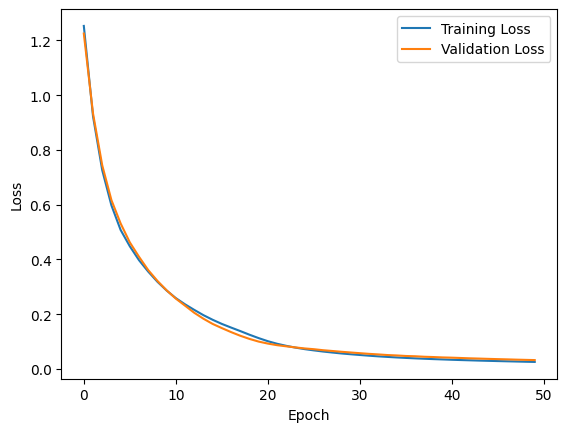

In [47]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])
plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


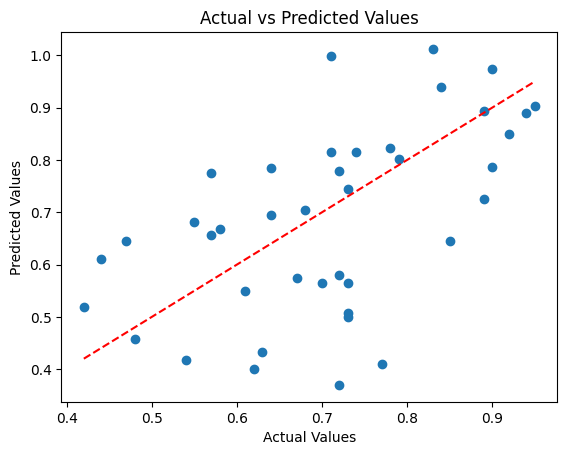

In [57]:
y_pred = model.predict(xtest)

actual = ytest.reshape(-1)
predicted = y_pred.reshape(-1)
plt.scatter(actual, predicted)

plt.plot(
    [actual.min(), actual.max()],
    [actual.min(), actual.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()